Notebook for the course [Master Hyperparameter Optimization for Tabular Learning](http://www.trainindata.com/p/master-hyperparameter-optimization-for-tabular-learning)

**Book-image equivalent of `02-TPE-plots-for-slides.ipynb`, implemented without Hyperopt or Seaborn.**

# Plots for the slides
## TPE - intuition

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import gaussian_kde

In [2]:
def plot_kde(values, label=None, color=None, rug=False, ax=None):
    ax = plt.gca() if ax is None else ax
    values = np.asarray(values, dtype=float)
    value_range = np.ptp(values)
    grid = np.linspace(values.min() - value_range * 0.15,
                       values.max() + value_range * 0.15, 500)
    density = gaussian_kde(values)(grid)
    ax.plot(grid, density, label=label, color=color)
    if rug:
        rug_height = max(density) * 0.035
        ax.vlines(values, 0, rug_height, color=color, alpha=0.45, linewidth=0.7)
    return ax

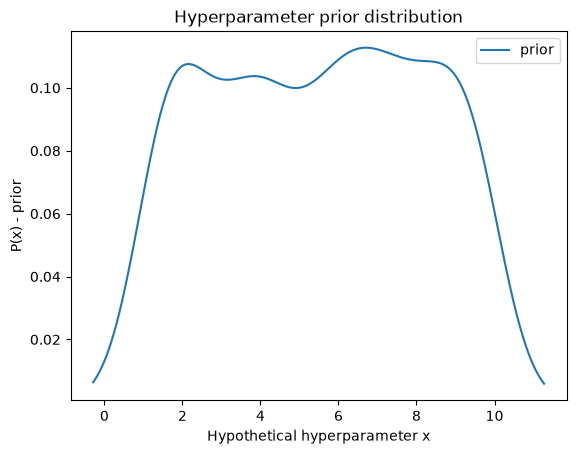

In [3]:
rng = np.random.RandomState(42)
prior_samples = rng.uniform(1, 10, size=500)

plot_kde(prior_samples, label='prior')
plt.title('Hyperparameter prior distribution')
plt.legend()
plt.xlabel('Hypothetical hyperparameter x')
plt.ylabel('P(x) - prior')
plt.show()

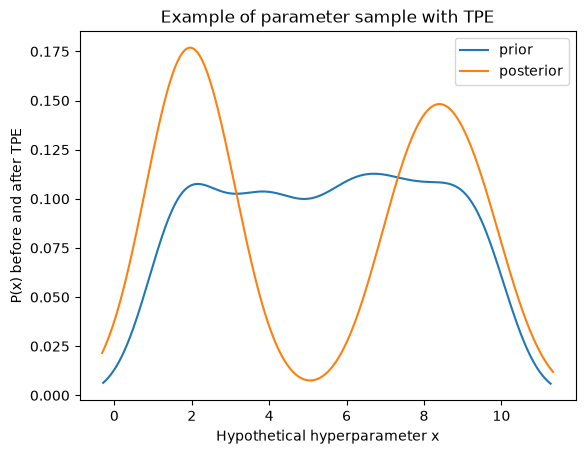

In [4]:
rng = np.random.RandomState(42)
prior_samples = rng.uniform(1, 10, size=500)
posterior_samples = np.concatenate([
    rng.uniform(1, 3, size=250),
    rng.uniform(7, 10, size=250),
])

plot_kde(prior_samples, label='prior')
plot_kde(posterior_samples, label='posterior')
plt.title('Example of parameter sample with TPE')
plt.legend()
plt.xlabel('Hypothetical hyperparameter x')
plt.ylabel('P(x) before and after TPE')
plt.show()

## TPE procedure

In [5]:
noise_level = 0.1
objective_rng = np.random.RandomState(237)

def objective(x, noise_level=noise_level):
    x = np.asarray(x)
    return (
        np.sin(5 * x[0]) * (1 - np.tanh(x[0] ** 2))
        + objective_rng.randn() * noise_level
    )

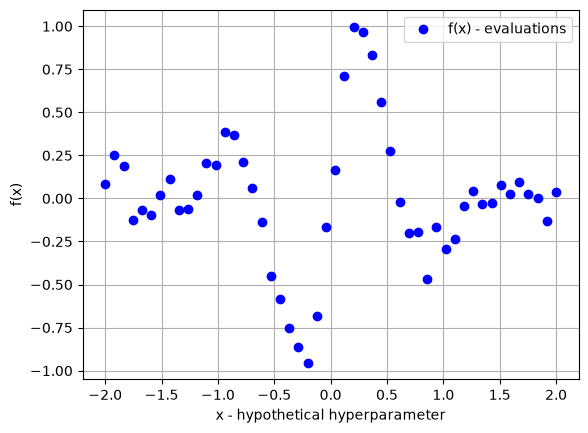

In [6]:
x = np.linspace(-2, 2, 50).reshape(-1, 1)
fx = np.array([objective(x_i) for x_i in x])

plt.plot(x, fx, 'bo', label='f(x) - evaluations')
plt.legend()
plt.grid()
plt.ylabel('f(x)')
plt.xlabel('x - hypothetical hyperparameter')
plt.show()

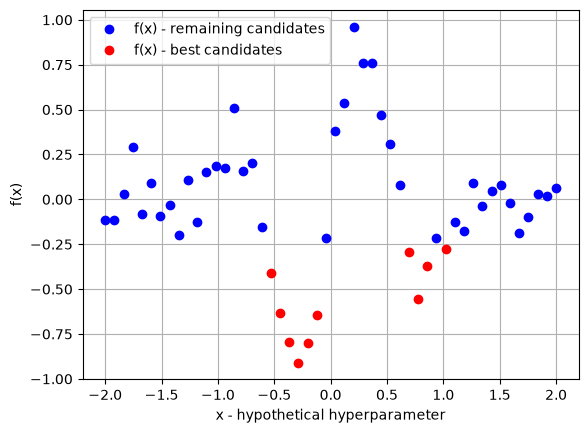

In [7]:
# Split evaluations into the good l(x) and remaining g(x) groups.
x = np.linspace(-2, 2, 50).reshape(-1, 1)
fx = np.array([objective(x_i) for x_i in x])
is_good = fx < -0.25

plt.plot(x[~is_good], fx[~is_good], 'bo', label='f(x) - remaining candidates')
plt.plot(x[is_good], fx[is_good], 'ro', label='f(x) - best candidates')
plt.legend()
plt.grid()
plt.ylabel('f(x)')
plt.xlabel('x - hypothetical hyperparameter')
plt.show()

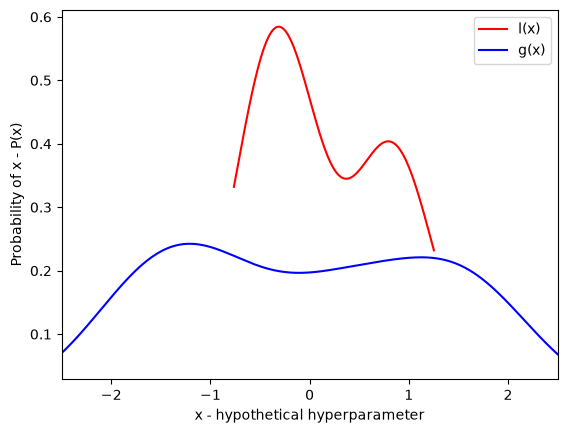

In [8]:
good_x = x[is_good].reshape(-1)
remaining_x = x[~is_good].reshape(-1)

plot_kde(good_x, label='l(x)', color='r')
plot_kde(remaining_x, label='g(x)', color='b')
plt.legend()
plt.xlim(-2.5, 2.5)
plt.ylabel('Probability of x - P(x)')
plt.xlabel('x - hypothetical hyperparameter')
plt.show()

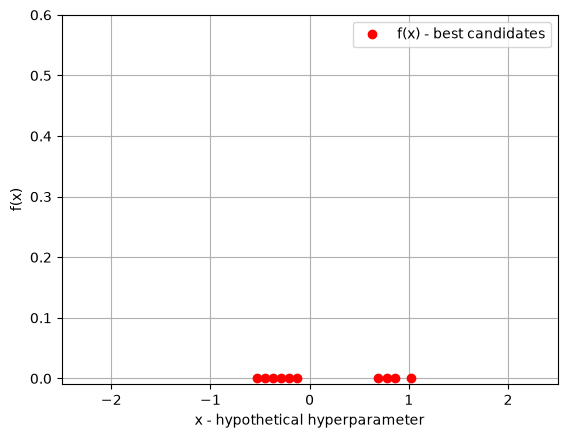

In [9]:
plt.plot(good_x, np.zeros_like(good_x), 'ro', label='f(x) - best candidates')
plt.legend()
plt.grid()
plt.ylabel('f(x)')
plt.xlabel('x - hypothetical hyperparameter')
plt.ylim(-0.01, 0.6)
plt.xlim(-2.5, 2.5)
plt.show()

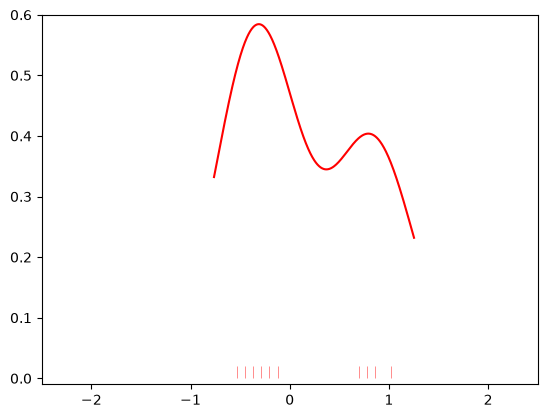

In [10]:
plot_kde(good_x, color='r', rug=True)
plt.ylim(-0.01, 0.6)
plt.xlim(-2.5, 2.5)
plt.show()

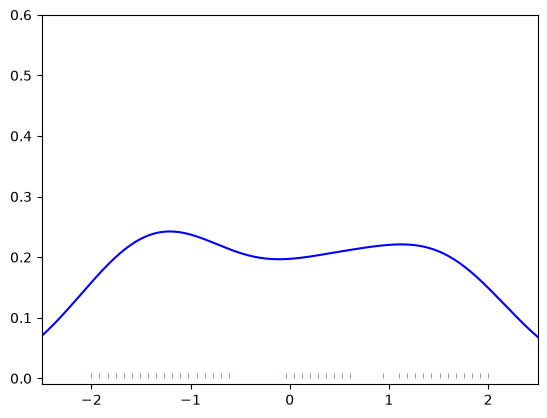

In [11]:
plot_kde(remaining_x, color='b', rug=True)
plt.ylim(-0.01, 0.6)
plt.xlim(-2.5, 2.5)
plt.show()